In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [172]:
# IMR90 AVE DEGREE
FILES = {
    0.10: "permutation_results_0.1_BET/plots_Rao_2014_IMR90_full_betweenness/pvals_betweenness.csv",
    0.15: "permutation_results_0.15_OPT/plots_Rao_2014_IMR90_full_betweenness/pvals_betweenness.csv",
    0.35: "permutation_results_0.35_BET/plots_Rao_2014_IMR90_full_betweenness/pvals_betweenness.csv",
}

In [ ]:
# IMR90 BETWEENNESS
FILES = {
    0.10: "permutation_results_0.1_BET/plots_Rao_2014_IMR90_full_betweenness/pvals_betweenness.csv",
    0.15: "permutation_results_0.15_OPT/plots_Rao_2014_IMR90_full_betweenness/pvals_betweenness.csv",
    0.35: "permutation_results_0.35_BET/plots_Rao_2014_IMR90_full_betweenness/pvals_betweenness.csv",
}

In [ ]:
# HUVEC AVE DEGREE
FILES = {
    0.10: "permutation_results_0.1_HUV/plots_Rao_2014_HUVEC_full_ave_degree/pvals_ave_degree.csv",
    0.20: "permutation_results_0.2_OPT/plots_Rao_2014_HUVEC_full_ave_degree/pvals_ave_degree.csv",
    0.35: "permutation_results_0.35_HUV/plots_Rao_2014_HUVEC_full_ave_degree/pvals_ave_degree.csv",
}

In [ ]:
# HUVEC BETWEENNESS
FILES = {
    0.10: "permutation_results_0.1_BET/plots_Rao_2014_HUVEC_full_betweenness/pvals_betweenness.csv",
    0.20: "permutation_results_0.2_OPT/plots_Rao_2014_HUVEC_full_betweenness/pvals_betweenness.csv",
    0.35: "permutation_results_0.35_BET/plots_Rao_2014_HUVEC_full_betweenness/pvals_betweenness.csv"
}

In [184]:
dfs = [pd.read_csv(f, index_col=0) for f in FILES.values()]
for thr, df in zip(FILES.keys(), dfs):
    df["threshold"] = thr
dfs = pd.concat(dfs)

In [185]:
dfs.sort_values(["a", "b", "threshold"], inplace=True)

In [186]:
sig_column = [1 if v < 0.05 else 0 for v in dfs["a > b"]]
sig_column = [-1 if v > 0.95 else e for e, v in zip(sig_column, dfs["a > b"])]

In [187]:
dfs.loc[dfs["a"] == "1_TssA", "a"] = "TssA"
dfs.loc[dfs["a"] == "7_Enh", "a"] = "Enhancer"
dfs.loc[dfs["b"] == "Bound", "b"] = "Boundary"
dfs.loc[dfs["b"] == "universe", "b"] = "Universe"

In [188]:
dfs

,a != b,a > b,a < b,chr,a,b,threshold
0,0.033,0.981,0.019,14,TssA,Boundary,0.10
4,0.000,1.000,0.000,6,TssA,Boundary,0.10
8,0.000,1.000,0.000,21,TssA,Boundary,0.10
12,0.000,1.000,0.000,12,TssA,Boundary,0.10
16,0.000,1.000,0.000,2,TssA,Boundary,0.10
...,...,...,...,...,...,...,...
79,0.657,0.663,0.337,22,Enhancer,Universe,0.35
83,0.004,0.999,0.001,15,Enhancer,Universe,0.35
87,0.055,0.974,0.026,19,Enhancer,Universe,0.35
91,0.908,0.452,0.548,13,Enhancer,Universe,0.35


In [189]:
dfs["significance"] = sig_column
dfs["test"] = dfs["a"] + "\n vs \n" + dfs["b"]

dfs.drop(["a > b", "a < b", "a != b", "a", "b"], axis=1, inplace=True)

In [190]:
dfs["threshold"] = dfs["threshold"].astype(str)

In [191]:
dfs["threshold"] = ["0.10" if v == "0.1" else v for v in dfs["threshold"]]

In [192]:
tests = dfs["test"].unique().tolist()

In [193]:
mult_dfs = {t: dfs[dfs["test"] == t].drop("test", axis=1) for t in tests} 

In [194]:
mult_dfs = {k: pd.pivot(v, values="significance", index="threshold", columns="chr") for k, v in mult_dfs.items()}

In [195]:
CHR_ORDER = [str(v) for v in range(1, 23)] + ["X", "Y"]
mult_dfs = {k: v[CHR_ORDER] for k, v in mult_dfs.items()}

In [196]:
mult_dfs

{'TssA\n vs \nBoundary': chr        1  2  3  4  5  6  7  8  9  10  ...  15  16  17  18  19  20  21  22  \
 threshold                                 ...                                   
 0.10      -1 -1 -1 -1 -1 -1 -1 -1 -1  -1  ...  -1   0   0  -1   0  -1  -1  -1   
 0.15       0  0  0  0  0 -1  0 -1 -1   0  ...   0   0   0  -1   0   0  -1  -1   
 0.35       1  1  1  1  1  1  1  1  1   1  ...   1   1   1   1   1   1   0   1   
 
 chr        X  Y  
 threshold        
 0.10      -1  0  
 0.15      -1  0  
 0.35       0  0  
 
 [3 rows x 24 columns],
 'TssA\n vs \nUniverse': chr        1  2  3  4  5  6  7  8  9  10  ...  15  16  17  18  19  20  21  22  \
 threshold                                 ...                                   
 0.10       0  0  0  0  0  0  0 -1  0   0  ...   0   1   0   0   0   0   0  -1   
 0.15       1  1  0  0  1  0  0 -1  0   0  ...   0   1   0  -1   0   1  -1  -1   
 0.35      -1 -1 -1  0  0 -1  1  0 -1   0  ...  -1   0   0  -1   0   1  -1   0   
 
 chr   

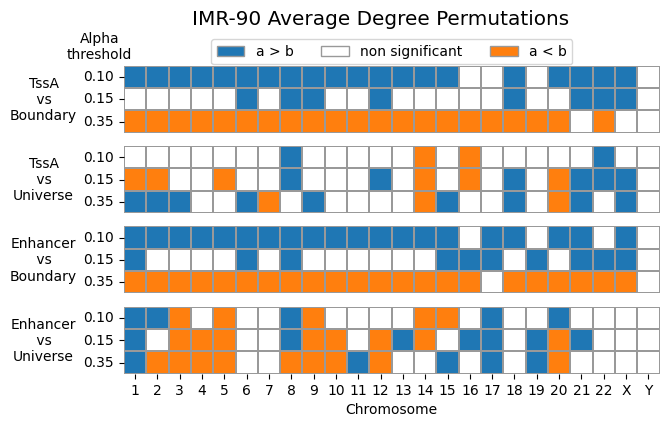

In [212]:
HEAT_PALETTE = [sns.color_palette("tab10")[0], (1,1,1), sns.color_palette("tab10")[1],]
GRAY = (0.6,0.6,0.6)
PATCHES = [
    mpatches.Patch(color=sns.color_palette("tab10")[0], label='a > b', ec=GRAY),
    mpatches.Patch(color=(1,1,1), label='non significant', ec=GRAY),
    mpatches.Patch(color=sns.color_palette("tab10")[1], label='a < b', ec=GRAY),
]


fig, ax = plt.subplots(nrows=len(mult_dfs), ncols=1, figsize=(9,4))
counter = 0
for (t, d), a in zip(mult_dfs.items(), ax):
    counter += 1
    
    if counter != len(mult_dfs):
        a = sns.heatmap(
            d, 
            cmap=HEAT_PALETTE, 
            square=True, 
            linewidth=0.01, 
            linecolor=GRAY, 
            ax=a, 
            cbar=False,
            xticklabels=False,
        )
        a.set(xlabel=None)
    else:
        a = sns.heatmap(
            d, 
            cmap=HEAT_PALETTE, 
            square=True, 
            linewidth=0.01, 
            linecolor=GRAY, 
            ax=a, 
            cbar=False,
            xticklabels=True,
        )
        a.set(xlabel="Chromosome")
    
    if counter == 1:
        a.legend(handles=PATCHES, loc="upper center",bbox_to_anchor=(0.5, 1.5), ncol=3, fancybox=True)
        a.text(-1.1, -0.3, "Alpha\nthreshold", horizontalalignment="center")
    
    a.set_ylabel(t, rotation=0, labelpad=10)
    a.yaxis.set_label_coords(-0.15, 0.15)

fig.suptitle("IMR-90 Average Degree Permutations", y=1.02, fontsize="x-large")

#ax.hlines([3, 6, 9], *ax.get_xlim(), colors="black", linewidths=3)

plt.show()

In [ ]:
sns.color_palette("tab10")[0]

In [ ]:
pd.MultiIndex.from_frame(dfs[["a", "b", "threshold"]])